# Hierarchical Demand Forecasting Explainability

This notebook demonstrates how to use the hierarchical feature importance module to analyze feature contributions across different levels of a forecasting hierarchy.

The methodology follows the approach from "Optimising Hierarchical Demand Forecasting with Explainable AI" which aggregates SHAP values at different hierarchy levels using cohort-based mean absolute SHAP values.

In [79]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

## 1. Create Hierarchical Sales Data

We'll simulate multi-year weekly sales data with a hierarchical structure similar to the M5 competition:
- **State** (top level): TX, WI
- **Store** (mid level): multiple stores per state
- **Product** (bottom level): multiple products per store

The synthetic process includes trend, seasonality, promotions, holiday effects, and autoregressive lag behavior to make the series more realistic.

In [80]:
np.random.seed(42)

# Define hierarchy
states = ['TX', 'WI']
stores_per_state = {'TX': ['TX_S1', 'TX_S2', 'TX_S3'], 'WI': ['WI_S1', 'WI_S2']}
products = ['P1', 'P2']

# Multi-year weekly horizon
n_years = 4
n_weeks = 52 * n_years
start_date = pd.Timestamp('2020-01-05')

# Generate hierarchical data
rows = []

for state in states:
    # State-level effects
    state_price_sensitivity = 0.30 if state == 'TX' else 0.50
    state_seasonal_strength = 1.0 if state == 'TX' else 1.4
    
    for store in stores_per_state[state]:
        # Store-level effects
        store_base = np.random.uniform(100, 200)
        store_event_sensitivity = np.random.uniform(0.7, 1.4)
        
        for product in products:
            # Product-level effects
            product_base = np.random.uniform(50, 100)
            series_trend_per_year = np.random.uniform(1.5, 3.5)
            price_level = np.random.uniform(9.5, 12.5)

            # Keep a history to generate realistic lag features
            sales_history = []
            
            for week in range(n_weeks):
                # Time features
                date = start_date + pd.Timedelta(weeks=week)
                week_of_year = (week % 52) + 1
                year_index = week // 52
                is_holiday_season = int(week_of_year >= 47)

                # Exogenous drivers with realistic dependencies
                promotion = np.random.binomial(1, 0.08 + 0.12 * is_holiday_season)
                sell_price = np.clip(
                    price_level
                    + 0.15 * year_index
                    + np.random.normal(0, 0.6)
                    - promotion * np.random.uniform(0.8, 1.8),
                    7.0,
                    18.0,
                )
                num_events = np.random.poisson(0.4 + 0.6 * is_holiday_season + 0.2 * promotion)
                snap_days = np.random.binomial(5, 0.35 + 0.15 * is_holiday_season)

                # Lag features from actual generated history
                base_lag = product_base + 0.2 * store_base
                lag_1 = sales_history[-1] if len(sales_history) >= 1 else base_lag
                lag_4 = sales_history[-4] if len(sales_history) >= 4 else base_lag
                lag_13 = sales_history[-13] if len(sales_history) >= 13 else base_lag
                lag_52 = sales_history[-52] if len(sales_history) >= 52 else base_lag

                # More realistic sales process: trend + multiple seasonalities + AR lags + effects
                seasonality = state_seasonal_strength * (
                    18 * np.sin(2 * np.pi * week_of_year / 52)
                    + 6 * np.cos(4 * np.pi * week_of_year / 52)
                )
                trend = series_trend_per_year * year_index
                price_effect = -state_price_sensitivity * (sell_price - 10.5) * 7
                event_effect = store_event_sensitivity * num_events * 8
                snap_effect = snap_days * 2.2
                promo_effect = promotion * 8.0
                holiday_effect = is_holiday_season * 10.0

                expected_sales = (
                    product_base
                    + 0.35 * lag_1 + 0.18 * lag_4 + 0.08 * lag_13 + 0.04 * lag_52
                    + seasonality + trend
                    + price_effect + event_effect + snap_effect
                    + promo_effect + holiday_effect
                )

                sales = max(0.0, expected_sales + np.random.normal(0, 9 + 2 * is_holiday_season))
                sales_history.append(sales)

                rows.append({
                    'state_id': state,
                    'store_id': store,
                    'product_id': product,
                    'series_id': f"{store}_{product}",
                    'date': date,
                    'week_of_year': week_of_year,
                    'promotion': promotion,
                    'is_holiday_season': is_holiday_season,
                    'sell_price': sell_price,
                    'num_events': num_events,
                    'snap_days': snap_days,
                    'lag_1': lag_1,
                    'lag_4': lag_4,
                    'lag_13': lag_13,
                    'lag_52': lag_52,
                    'sales': sales,
                })

df = pd.DataFrame(rows).sort_values(['series_id', 'date']).reset_index(drop=True)
print(f"Data shape: {df.shape}")
print(f"Date range: {df['date'].min().date()} -> {df['date'].max().date()}")
print(f"Years simulated: {n_years}")
print(f"\nHierarchy structure:")
print(f"  States: {df['state_id'].nunique()}")
print(f"  Stores: {df['store_id'].nunique()}")
print(f"  Products: {df['product_id'].nunique()}")
print(f"  Series: {df['series_id'].nunique()}")
df.head()

Data shape: (2080, 16)
Date range: 2020-01-05 -> 2023-12-24
Years simulated: 4

Hierarchy structure:
  States: 2
  Stores: 5
  Products: 2
  Series: 10


,state_id,store_id,product_id,series_id,date,week_of_year,promotion,is_holiday_season,sell_price,num_events,snap_days,lag_1,lag_4,lag_13,lag_52,sales
0,TX,TX_S1,P1,TX_S1_P1,2020-01-05,1,0,0,10.915584,2,1,114.090499,114.090499,114.090499,114.090499,198.836020
1,TX,TX_S1,P1,TX_S1_P1,2020-01-12,2,0,0,10.113233,0,2,198.836020,114.090499,114.090499,114.090499,188.032560
2,TX,TX_S1,P1,TX_S1_P1,2020-01-19,3,0,0,9.423241,1,2,188.032560,114.090499,114.090499,114.090499,202.386655
3,TX,TX_S1,P1,TX_S1_P1,2020-01-26,4,0,0,10.041387,0,4,202.386655,114.090499,114.090499,114.090499,208.559747
4,TX,TX_S1,P1,TX_S1_P1,2020-02-02,5,1,0,8.710231,1,1,208.559747,198.836020,114.090499,114.090499,254.839219


C:\Users\MKU4CLJ\AppData\Local\Temp\ipykernel_56580\799803608.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: plt.plot(x['date'], x['sales'], label=x['series_id'].iloc[0]))


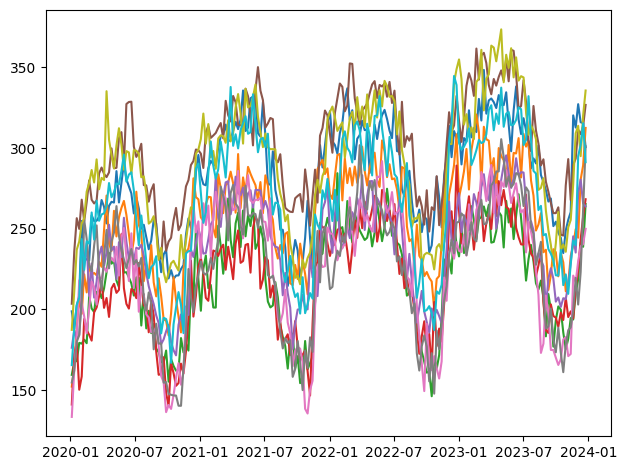

In [81]:
# Plot the series over time in one figure with different colors for each series
(
    df.sort_values(['series_id', 'date'])
    .groupby('series_id')
    .apply(lambda x: plt.plot(x['date'], x['sales'], label=x['series_id'].iloc[0]))
)
plt.tight_layout()

## 2. Train a skforecast Model

We'll train a global `ForecasterRecursiveMultiSeries` model with a RandomForest regressor and extract the training matrix for explainability.

In [121]:
from skforecast.recursive import ForecasterRecursiveMultiSeries
from xeries.adapters.skforecast import from_skforecast

# Exogenous feature columns available in the data
EXOG_COLS = ['week_of_year', 'sell_price', 'num_events', 'snap_days', 'promotion', 'is_holiday_season']

# Build wide-format series required by skforecast
series_wide = (
    df.pivot(index='date', columns='series_id', values='sales')
    .sort_index()
    .asfreq('W-SUN')
)

# Build per-series exog dict (each series has its own price/promo/events)
exog_dict = {
    sid: (
        df[df['series_id'] == sid]
        .set_index('date')[EXOG_COLS]
        .sort_index()
        .asfreq('W-SUN')
    )
    for sid in series_wide.columns
}

# Train global multi-series forecaster with exogenous variables
forecaster = ForecasterRecursiveMultiSeries(
    estimator=RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42),
    lags=[1, 4, 13, 52],
    encoding='ordinal',
)
forecaster.fit(series=series_wide, exog=exog_dict)

# Adapter exposes the exact training matrix used by skforecast
adapter = from_skforecast(forecaster, series=series_wide, exog=exog_dict)
X, y = adapter.get_training_data()
series_col = adapter.get_series_column()

# Use full training columns for SHAP so input dims match fitted estimator
feature_cols = list(X.columns)
predictor_cols = adapter.get_feature_names()

print(f"Training matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Predictor columns (excl. series code): {predictor_cols}")
print(f"Series column in training matrix: {series_col}")
print(f"All SHAP feature columns: {feature_cols}")

# Check in-sample fit on the extracted matrix
predictions = adapter.predict(X)
mse = np.mean((y.values - predictions) ** 2)
print(f"Training MSE (adapter matrix): {mse:.2f}")

╭────────────────────────────────── InputTypeWarning ──────────────────────────────────╮
│ Passing a DataFrame (either wide or long format) as `series` requires additional     │
│ internal transformations, which can increase computational time. It is recommended   │
│ to use a dictionary of pandas Series instead. For more details, see:                 │
│ https://skforecast.org/latest/user_guides/independent-multi-time-series-forecasting. │
│ html#input-data                                                                      │
│                                                                                      │
│ Category : skforecast.exceptions.InputTypeWarning                                    │
│ Location :                                                                           │
│ c:\Workspace\Research\time_conditional_pfi\.venv\Lib\site-packages\skforecast\utils\ │
│ utils.py:2568                                                                        │
│ Suppress : warnings.simplefilter('ignore', category=InputTypeWarning)                │
╰──────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────── InputTypeWarning ──────────────────────────────────╮
│ Passing a DataFrame (either wide or long format) as `series` requires additional     │
│ internal transformations, which can increase computational time. It is recommended   │
│ to use a dictionary of pandas Series instead. For more details, see:                 │
│ https://skforecast.org/latest/user_guides/independent-multi-time-series-forecasting. │
│ html#input-data                                                                      │
│                                                                                      │
│ Category : skforecast.exceptions.InputTypeWarning                                    │
│ Location :                                                                           │
│ c:\Workspace\Research\time_conditional_pfi\.venv\Lib\site-packages\skforecast\utils\ │
│ utils.py:2568                                                                        │
│ Suppress : warnings.simplefilter('ignore', category=InputTypeWarning)                │
╰──────────────────────────────────────────────────────────────────────────────────────╯

Training matrix shape: (1560, 11)
Target shape: (1560,)
Predictor columns (excl. series code): ['lag_1', 'lag_4', 'lag_13', 'lag_52', 'week_of_year', 'sell_price', 'num_events', 'snap_days', 'promotion', 'is_holiday_season']
Series column in training matrix: _level_skforecast
All SHAP feature columns: ['lag_1', 'lag_4', 'lag_13', 'lag_52', '_level_skforecast', 'week_of_year', 'sell_price', 'num_events', 'snap_days', 'promotion', 'is_holiday_season']
Training MSE (adapter matrix): 24.40


c:\Workspace\Research\time_conditional_pfi\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


## 3. Define Hierarchy Structure

Use `HierarchyDefinition` with an explicit mapping from skforecast's encoded series IDs back to state/store/product.

In [117]:
from xeries.hierarchy import HierarchyDefinition, HierarchicalAggregator, HierarchicalResult

# Build mapping from original series names to hierarchy labels
series_meta = (
    df[['series_id', 'state_id', 'store_id', 'product_id']]
    .drop_duplicates()
    .set_index('series_id')
 )

# Resolve series identifiers from training matrix (index level or column)
if isinstance(X.index, pd.MultiIndex) and series_col in X.index.names:
    series_ids_train = X.index.get_level_values(series_col)
else:
    series_ids_train = X[series_col]

unique_ids = sorted(pd.Index(series_ids_train).unique().tolist())

# Decode to original series names when skforecast uses ordinal encoding
if series_col == '_level_skforecast':
    decoded_names = adapter.get_series_ids()
    id_to_series_name = dict(zip(unique_ids, decoded_names, strict=True))
else:
    id_to_series_name = {sid: sid for sid in unique_ids}

explicit_mapping = {}
for sid, name in id_to_series_name.items():
    meta = series_meta.loc[name]
    explicit_mapping[sid] = {
        'state': meta['state_id'],
        'store': meta['store_id'],
        'product': meta['product_id'],
    }

hierarchy = HierarchyDefinition(
    levels=['state', 'store', 'product'],
    explicit_mapping=explicit_mapping,
    series_col=series_col,
 )

print(hierarchy)

# Check cohorts at each level on skforecast training matrix
for level in hierarchy.levels:
    cohorts = hierarchy.get_cohorts(X, level)
    print(f"\n{level.title()} level cohorts: {list(cohorts.keys())[:5]} ... total={len(cohorts)}")

HierarchyDefinition(levels=['state', 'store', 'product'], strategy='explicit')

State level cohorts: ['TX', 'WI'] ... total=2

Store level cohorts: ['TX_TX_S1', 'TX_TX_S2', 'TX_TX_S3', 'WI_WI_S1', 'WI_WI_S2'] ... total=5

Product level cohorts: ['TX_TX_S1_P1', 'TX_TX_S1_P2', 'TX_TX_S2_P1', 'TX_TX_S2_P2', 'TX_TX_S3_P1'] ... total=10


## 4. Compute Hierarchical SHAP Values

We'll compute **real** SHAP values using `ConditionalSHAP` from xeries and aggregate them across hierarchy levels.

To keep runtime reasonable in this notebook, we explain a small sample per series.

In [122]:
import warnings

from xeries.core.types import SHAPResult
from xeries.importance import ConditionalSHAP

# Explain a small sample per series for notebook-speed runtime
samples_per_series = 3
if series_col in X.columns:
    X_explain = (
        X.groupby(series_col, group_keys=False)
        .sample(n=samples_per_series, random_state=42)
        .sort_index()
    )
else:
    X_explain = (
        X.groupby(level=series_col, group_keys=False)
        .sample(n=samples_per_series, random_state=42)
        .sort_index()
    )

# ConditionalSHAP on the skforecast training matrix via adapter
shap_explainer = ConditionalSHAP(
    model=adapter,
    background_data=X,
    series_col=series_col,
    n_background_samples=40,
    random_state=42,
 )

# Compute SHAP values on full skforecast training columns
with warnings.catch_warnings():
    warnings.filterwarnings(
        'ignore',
        message='X does not have valid feature names, but RandomForestRegressor was fitted with feature names',
        category=UserWarning,
    )
    raw_shap_result = shap_explainer.explain(
        X_explain,
        feature_names=feature_cols,
    )

# Drop the technical series-encoding feature from interpretation
interpretable_features = [f for f in feature_cols if f != series_col]
feature_idx = [raw_shap_result.feature_names.index(f) for f in interpretable_features]
shap_result = SHAPResult(
    shap_values=raw_shap_result.shap_values[:, feature_idx],
    base_values=raw_shap_result.base_values,
    feature_names=interpretable_features,
    data=X_explain[interpretable_features],
 )

print(f"Explained rows: {len(X_explain)}")
print(f"SHAP values shape: {shap_result.shap_values.shape}")
print("\nGlobal mean absolute SHAP values:")
shap_result.mean_abs_shap()

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Explained rows: 30
SHAP values shape: (30, 10)

Global mean absolute SHAP values:


,feature,mean_abs_shap
0,lag_1,20.649232
3,lag_52,5.361525
6,num_events,3.030935
4,week_of_year,2.038875
1,lag_4,1.908269
5,sell_price,0.978815
7,snap_days,0.809039
2,lag_13,0.622144
8,promotion,0.247887
9,is_holiday_season,0.223850


## 5. Aggregate SHAP Values Across Hierarchy Levels

Use `HierarchicalAggregator` to compute cohort-based mean absolute SHAP values at each level.

In [123]:
# Create aggregator and compute hierarchical importance
aggregator = HierarchicalAggregator(hierarchy)

# Aggregate SHAP values on the same explained subset
hierarchical_result = aggregator.aggregate_shap(
    shap_result,
    X_explain,
    levels=['state', 'store', 'product'],
    include_raw=True,
 )

print(hierarchical_result)
print(f"\nLevels: {hierarchical_result.levels}")
print(f"Features: {hierarchical_result.features}")

HierarchicalResult(levels=4, features=10, total_cohorts=18, method='shap')

Levels: ['global', 'state', 'store', 'product']
Features: ['lag_1', 'lag_4', 'lag_13', 'lag_52', 'week_of_year', 'sell_price', 'num_events', 'snap_days', 'promotion', 'is_holiday_season']


## 6. Visualize Global Feature Importance

Start with the global view showing overall feature importance.

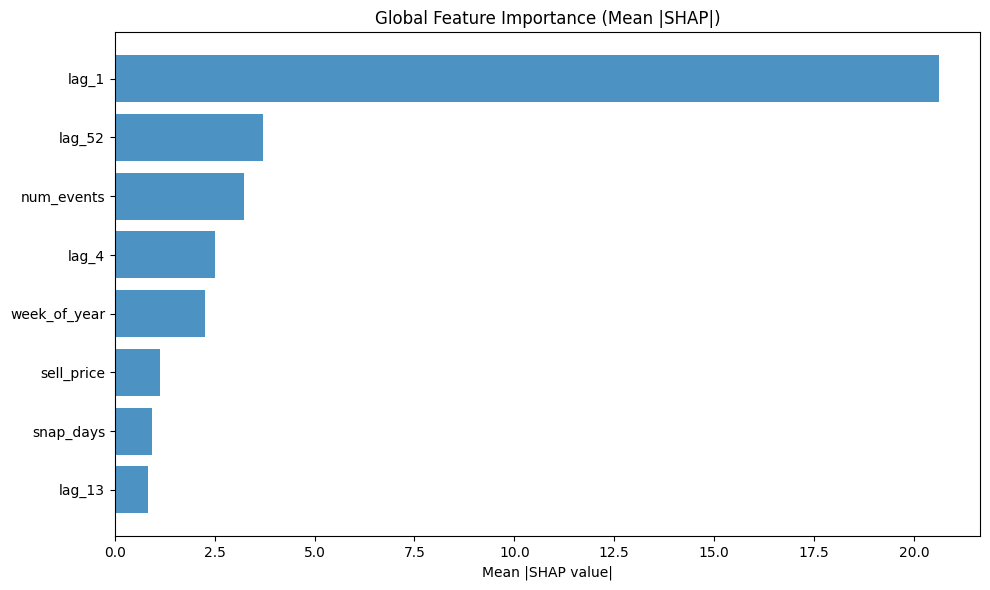

In [86]:
from xeries.visualization import plot_hierarchy_bar, plot_hierarchy_violin

# Global importance bar chart
fig, ax = plot_hierarchy_bar(
    hierarchical_result, 
    level='global',
    title='Global Feature Importance (Mean |SHAP|)'
)
plt.show()

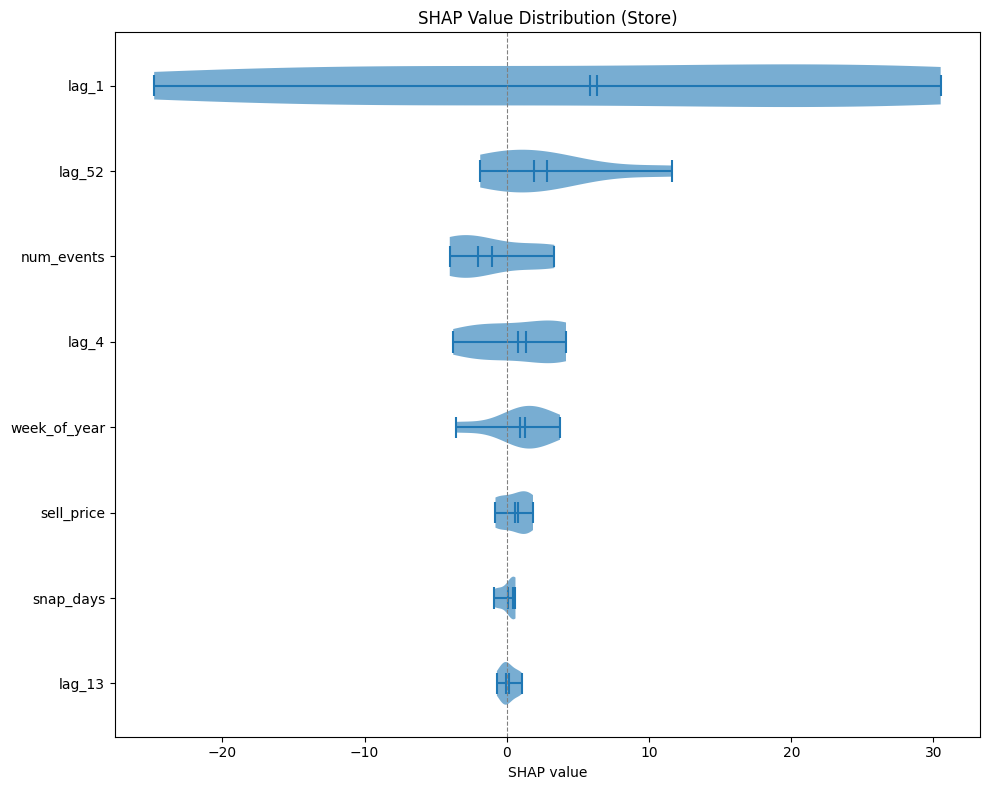

In [87]:
# Global violin plot showing SHAP value distribution
fig, ax = plot_hierarchy_violin(
    hierarchical_result,
    level='store',
    top_n=8,
    title='SHAP Value Distribution (Store)'
)
plt.show()

## 7. State-Level Analysis

Compare feature importance between TX and WI states.

In [88]:
# Get state-level importance as DataFrame
state_df = hierarchical_result.get_level_df('state')
print("State-level importance:")
state_df

State-level importance:


,week_of_year,sell_price,num_events,snap_days,lag_1,lag_4,lag_13,lag_52
WI,2.409978,1.282154,3.163148,0.962114,23.333661,3.236265,0.990698,3.254198
TX,2.147916,1.049382,3.286373,0.923996,18.815889,2.006281,0.728850,4.018910


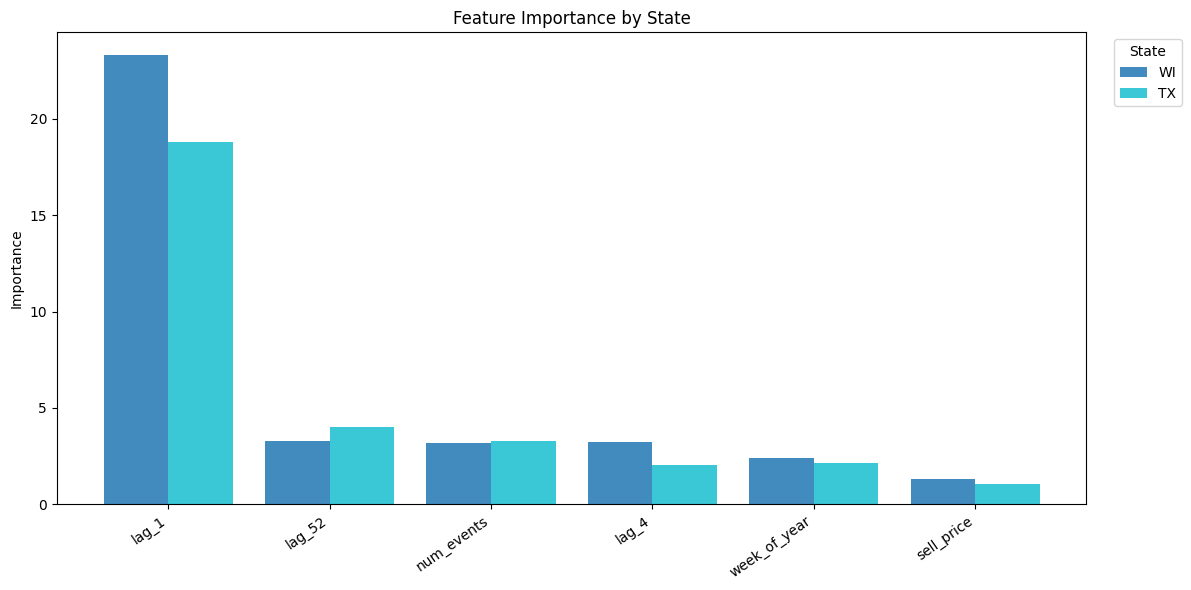

In [89]:
from xeries.visualization import plot_hierarchy_comparison

# Compare states
fig, ax = plot_hierarchy_comparison(
    hierarchical_result,
    level='state',
    top_n=6,
    title='Feature Importance by State'
)
plt.show()

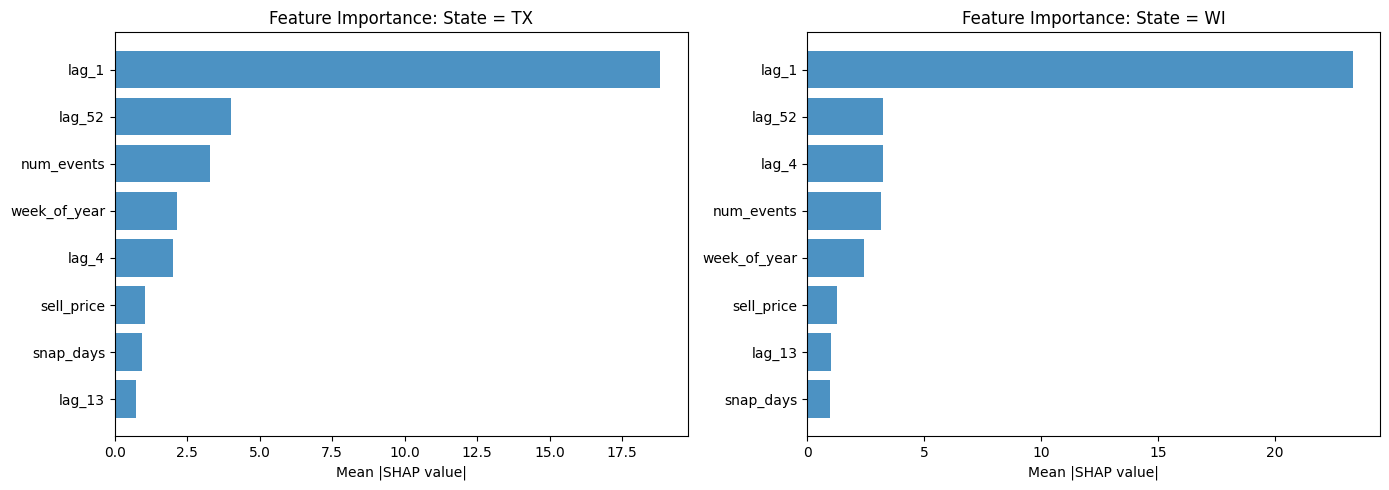

In [90]:
# Individual state bar charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_hierarchy_bar(hierarchical_result, level='state', cohort='TX', ax=axes[0])
plot_hierarchy_bar(hierarchical_result, level='state', cohort='WI', ax=axes[1])

plt.tight_layout()
plt.show()

## 8. Store-Level Analysis

Drill down to individual stores to see how importance varies.

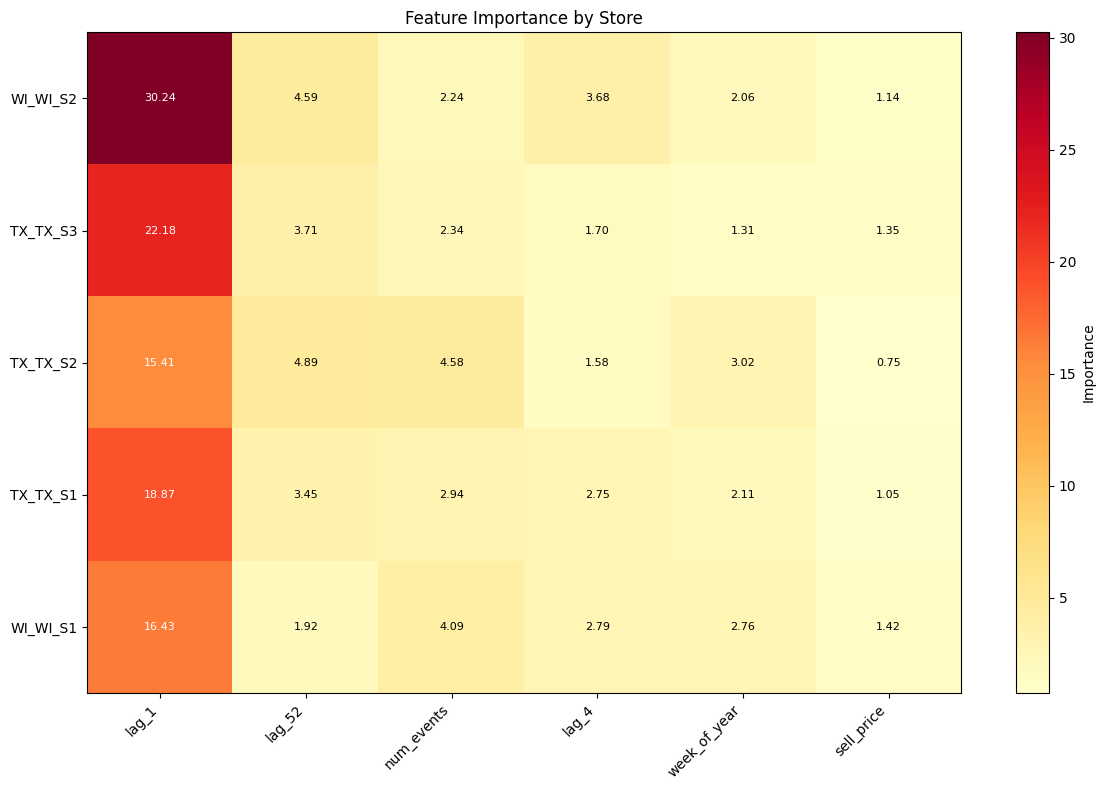

In [91]:
from xeries.visualization import plot_hierarchy_heatmap

# Heatmap of feature importance across stores
fig, ax = plot_hierarchy_heatmap(
    hierarchical_result,
    level='store',
    top_n=6,
    title='Feature Importance by Store'
)
plt.show()

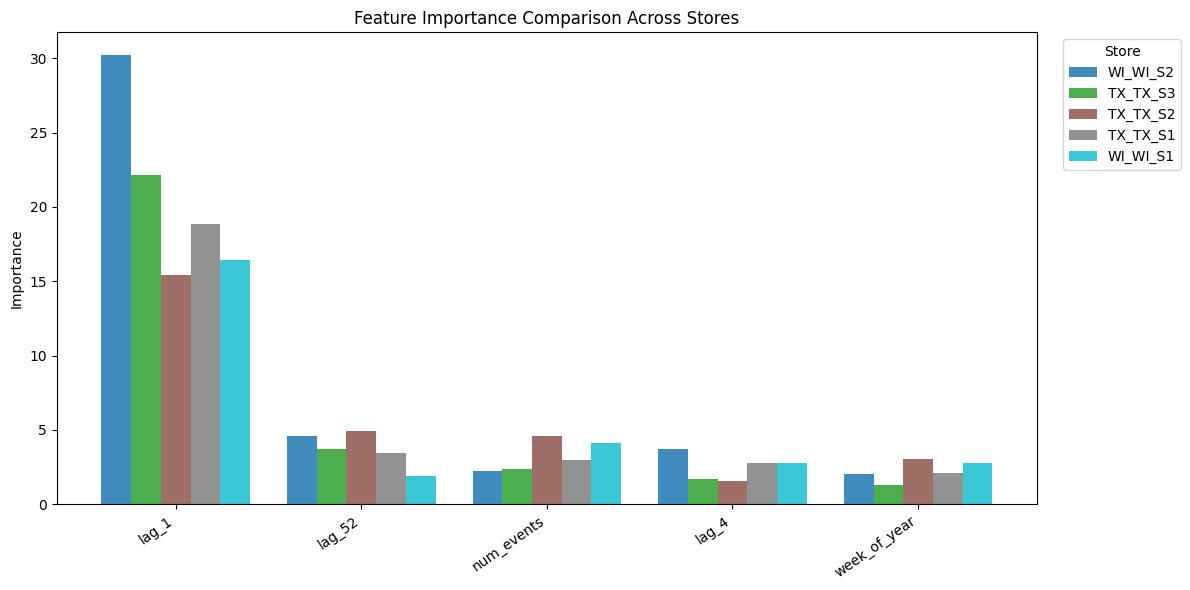

In [92]:
# Store-level comparison
fig, ax = plot_hierarchy_comparison(
    hierarchical_result,
    level='store',
    top_n=5,
    title='Feature Importance Comparison Across Stores'
)
plt.show()

## 9. Multi-Level Summary

View the complete hierarchy in a single summary plot.

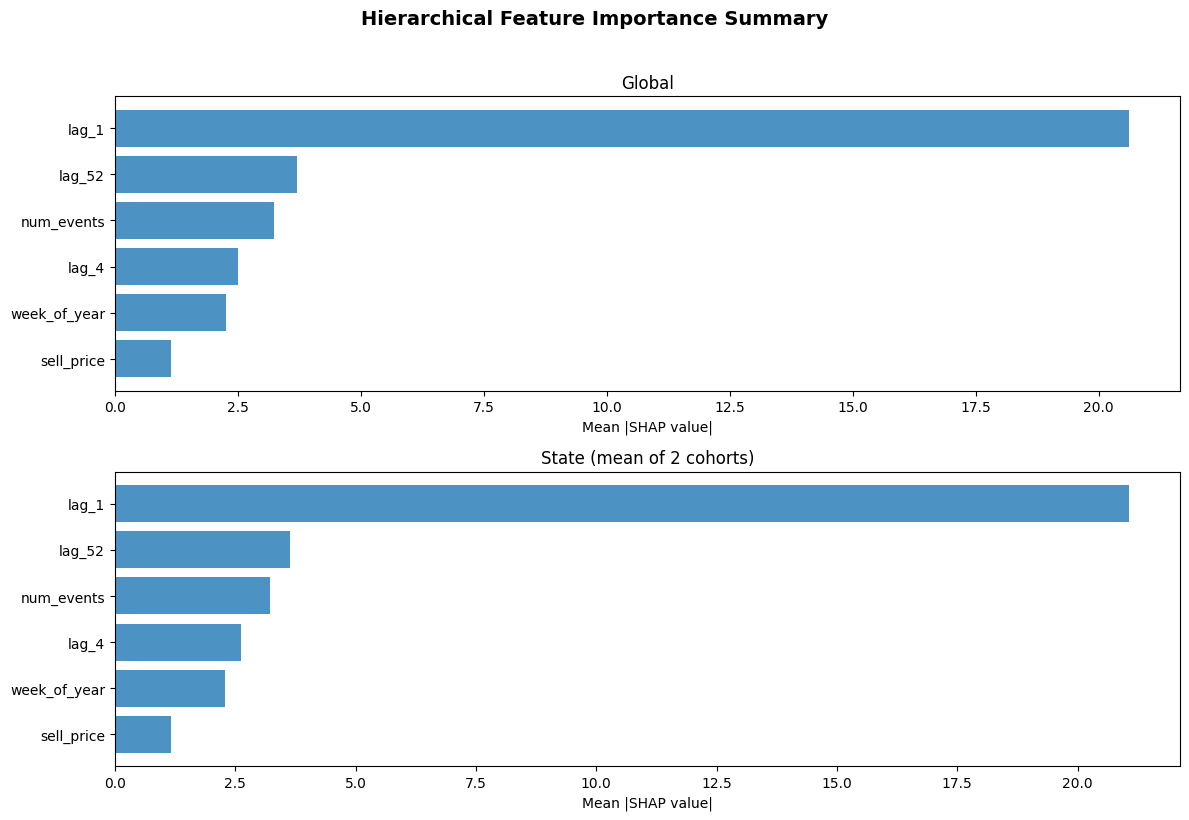

In [93]:
from xeries.visualization import plot_hierarchy_summary

# Multi-panel summary
fig, axes = plot_hierarchy_summary(
    hierarchical_result,
    levels=['global', 'state', ],
    top_n=6,
    title='Hierarchical Feature Importance Summary'
)
plt.show()

## 10. Feature-Specific Hierarchy View

Track how a single feature's importance changes through the hierarchy.

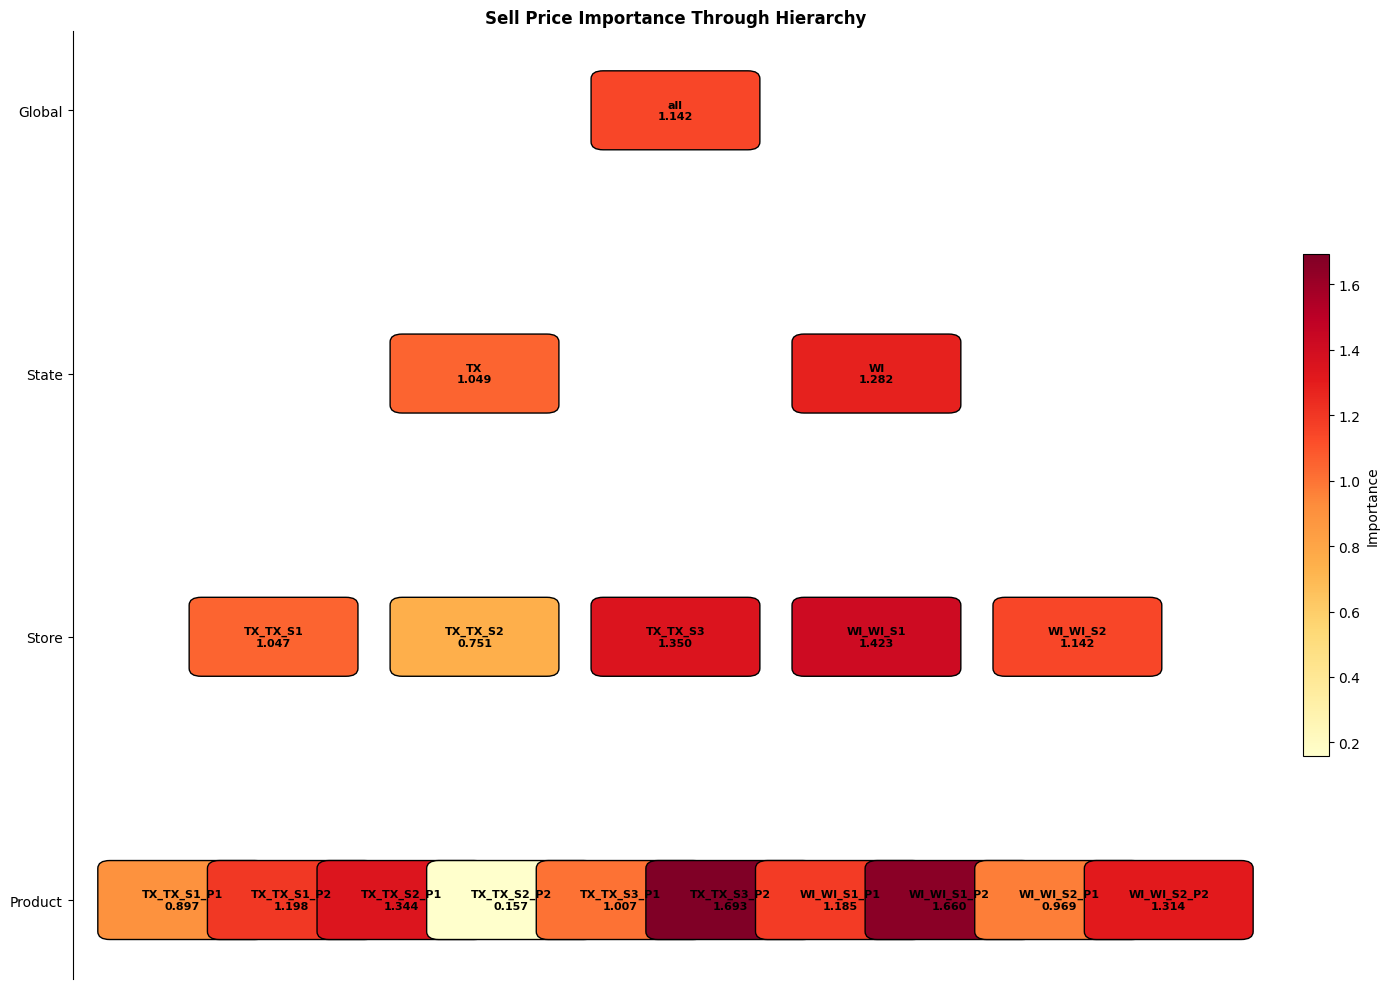

In [94]:
from xeries.visualization import plot_hierarchy_tree

# Tree view for a specific feature
fig, ax = plot_hierarchy_tree(
    hierarchical_result,
    feature='sell_price',
    title='Sell Price Importance Through Hierarchy'
)
plt.show()

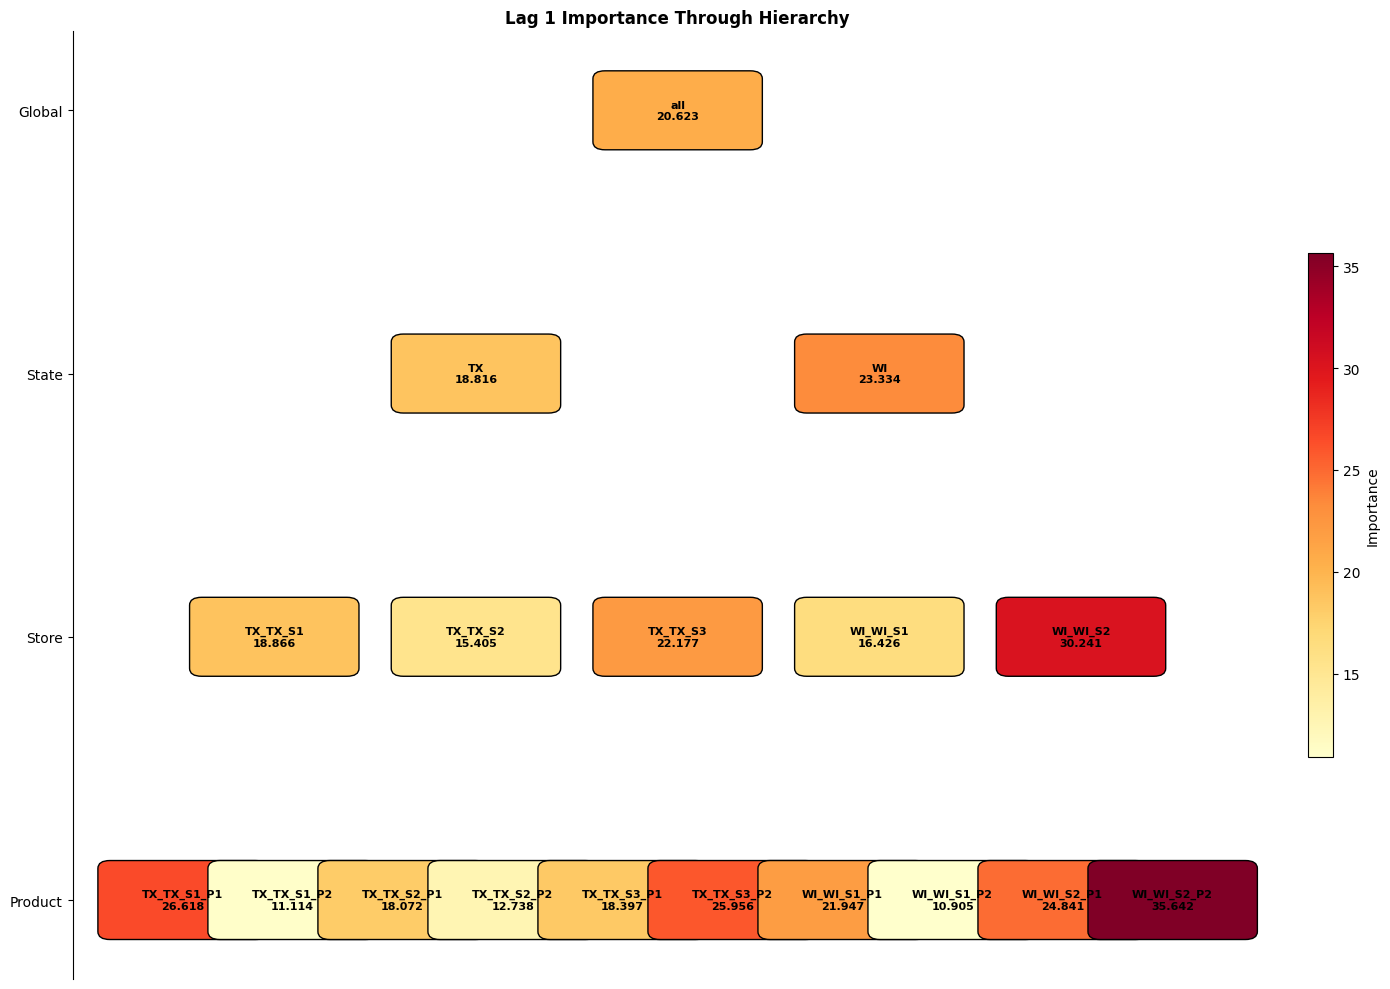

In [95]:
# Tree view for lag_1
fig, ax = plot_hierarchy_tree(
    hierarchical_result,
    feature='lag_1',
    title='Lag 1 Importance Through Hierarchy'
)
plt.show()

## 11. Export Results

Convert hierarchical results to DataFrames for further analysis.

In [96]:
# Long-form DataFrame with all results
full_df = hierarchical_result.to_dataframe()
print(f"Full results shape: {full_df.shape}")
full_df.head(10)

Full results shape: (144, 4)


,level,cohort,feature,importance
0,global,all,week_of_year,2.252741
1,global,all,sell_price,1.142491
2,global,all,num_events,3.237083
3,global,all,snap_days,0.939243
4,global,all,lag_1,20.622998
5,global,all,lag_4,2.498275
6,global,all,lag_13,0.833589
7,global,all,lag_52,3.713025
8,state,TX,week_of_year,2.147916
9,state,TX,sell_price,1.049382


In [97]:
# Pivot to get feature importance by cohort at store level
store_pivot = full_df[full_df['level'] == 'store'].pivot(
    index='cohort', 
    columns='feature', 
    values='importance'
)
store_pivot

feature,lag_1,lag_13,lag_4,lag_52,num_events,sell_price,snap_days,week_of_year
cohort,,,,,,,,
TX_TX_S1,18.865850,0.438805,2.745202,3.450143,2.943666,1.047428,0.562920,2.113587
TX_TX_S2,15.405076,1.376411,1.577746,4.894473,4.577173,0.750769,1.606284,3.019104
TX_TX_S3,22.176743,0.371334,1.695895,3.712115,2.338280,1.349951,0.602785,1.311055
WI_WI_S1,16.426009,1.553160,2.794843,1.919781,4.087218,1.422529,0.769834,2.764172
WI_WI_S2,30.241313,0.428237,3.677688,4.588614,2.239077,1.141780,1.154393,2.055784


## Summary

This notebook demonstrated the hierarchical feature importance module:

1. **HierarchyDefinition** - Define the hierarchical structure (state → store → product)
2. **HierarchicalAggregator** - Aggregate SHAP values at each level using cohort-based mean absolute values
3. **HierarchicalResult** - Access importance at any level via `get_level_df()`, `get_global()`, etc.
4. **Visualizations** - Multiple plot types for analyzing hierarchical importance:
   - `plot_hierarchy_bar` - Bar charts at any level
   - `plot_hierarchy_violin` - SHAP distributions
   - `plot_hierarchy_comparison` - Cross-cohort comparison
   - `plot_hierarchy_heatmap` - Heatmap view
   - `plot_hierarchy_summary` - Multi-level cascade
   - `plot_hierarchy_tree` - Feature-specific hierarchy view

Key insights from the hierarchical analysis:
- `lag_1` is consistently the most important feature across all levels
- `sell_price` importance varies by state (TX shows higher sensitivity)
- `week_of_year` (seasonality) matters more in WI than TX
- Store-level variations reveal local patterns not visible at aggregate level